# Task 5 - Movie Recommendation System

This project builds a movie recommendation system using the MovieLens 100K dataset.

The system uses collaborative filtering to recommend movies based on users' ratings. I will use similar users and similar movies to generate recommendations, and I will also try SVD as a bonus approach.

The recommendation quality will be evaluated using Precision@10.

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import os
import joblib

In [3]:
ratings = pd.read_csv(
    "data/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [4]:
movies = pd.read_csv(
    "data/u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0, 1, 2],
    names=["movie_id", "title", "release_date"]
)

movies.head()

,movie_id,title,release_date
0,1,Toy Story (1995),01-Jan-1995
1,2,GoldenEye (1995),01-Jan-1995
2,3,Four Rooms (1995),01-Jan-1995
3,4,Get Shorty (1995),01-Jan-1995
4,5,Copycat (1995),01-Jan-1995


In [5]:
print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

print("Ratings info:")
ratings.info()

print("Movies info:")
movies.info()

Ratings shape: (100000, 4)
Movies shape: (1682, 3)
Ratings info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
Movies info:
<class 'pandas.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   movie_id      1682 non-null   int64
 1   title         1682 non-null   str  
 2   release_date  1681 non-null   str  
dtypes: int64(1), str(2)
memory usage: 96.4 KB


## Data Understanding and Cleaning

I will check the data for missing values, duplicates, rating values, and the number of users and movies.

In [6]:
print("Missing values:")
print(ratings.isnull().sum())

print("\nDuplicate rows:", ratings.duplicated().sum())

print(
    "Duplicate user-movie pairs:",
    ratings.duplicated(
        subset=["user_id", "movie_id"]
    ).sum()
)

print(
    "\nRating range:",
    ratings["rating"].min(),
    "to",
    ratings["rating"].max()
)

print("\nNumber of users:", ratings["user_id"].nunique())
print("Number of movies:", ratings["movie_id"].nunique())

Missing values:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Duplicate rows: 0
Duplicate user-movie pairs: 0

Rating range: 1 to 5

Number of users: 943
Number of movies: 1682


In [7]:
print("Missing values:")
print(movies.isnull().sum())

print("\nDuplicate movie IDs:", movies["movie_id"].duplicated().sum())

missing_movie_ids = set(ratings["movie_id"]) - set(movies["movie_id"])

print("Missing movie IDs:", len(missing_movie_ids))

Missing values:
movie_id        0
title           0
release_date    1
dtype: int64

Duplicate movie IDs: 0
Missing movie IDs: 0


## Preparing Movie Data

The release date is not needed for the recommendation system, so I will remove it.

In [8]:
movies = movies.drop(columns=["release_date"])

movies.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


## Train-Test Split

I will split each user's ratings into training and test data.

The training data will be used to build the recommendation models, while the test data will be used to check how well the recommendations work.

In [9]:
train_ratings = []
test_ratings = []

for user_id, user_data in ratings.groupby("user_id"):
    user_data = user_data.sample(
        frac=1,
        random_state=42
    )

    split_index = int(len(user_data) * 0.8)

    train_ratings.append(
        user_data.iloc[:split_index]
    )

    test_ratings.append(
        user_data.iloc[split_index:]
    )

train_ratings = pd.concat(train_ratings)
test_ratings = pd.concat(test_ratings)

print("Training ratings:", train_ratings.shape)
print("Test ratings:", test_ratings.shape)

Training ratings: (79619, 4)
Test ratings: (20381, 4)


## User-Based Collaborative Filtering

I will start with user-based collaborative filtering.

The idea is to find users who have similar movie preferences and use their ratings to recommend movies to the target user.

### User-Item Matrix

I will create a matrix where each row represents a user and each column represents a movie. The values are the ratings given by each user in the training data.

In [10]:
train_user_item_matrix = train_ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)

train_user_item_matrix.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,3.0,NaN,3.0,NaN,NaN,NaN,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
print("Training matrix shape:", train_user_item_matrix.shape)
print(
    "Missing values:",
    train_user_item_matrix.isnull().sum().sum()
)

Training matrix shape: (943, 1655)
Missing values: 1481046


### Preparing the Training Matrix

Most users have not rated most movies, so there are many missing values in the matrix.

I will replace the missing values with 0 so I can calculate the similarity between users.

In [12]:
train_user_item_filled = train_user_item_matrix.fillna(0)

print(
    "Missing values after filling:",
    train_user_item_filled.isnull().sum().sum()
)

Missing values after filling: 0


### User Similarity

I will calculate the similarity between users using cosine similarity.

In [13]:
train_user_similarity = cosine_similarity(
    train_user_item_filled
)

print(
    "Similarity matrix shape:",
    train_user_similarity.shape
)

Similarity matrix shape: (943, 943)


### Finding Similar Users

I will use User 1 as an example and find the users with the most similar movie preferences based on the training data.

In [14]:
target_user = 1

user_index = train_user_item_filled.index.get_loc(
    target_user
)

similarity_scores = train_user_similarity[user_index]

similar_users = pd.Series(
    similarity_scores,
    index=train_user_item_filled.index
)

similar_users = similar_users.drop(target_user)

similar_users.sort_values(
    ascending=False
).head(10)

user_id
864    0.459025
303    0.456530
268    0.447074
435    0.442037
276    0.439347
457    0.433130
916    0.432598
429    0.428646
889    0.427073
293    0.426555
dtype: float64

### Generating Recommendations

I will use the most similar users to generate movie recommendations.

Movies will be scored using a weighted average, so users with higher similarity will have more influence on the score.

In [15]:
top_similar_users = similar_users.sort_values(
    ascending=False
).head(50)

similar_user_ratings = train_user_item_matrix.loc[
    top_similar_users.index
]

weighted_scores = (
    similar_user_ratings.fillna(0).T.dot(
        top_similar_users
    )
)

rating_weights = (
    similar_user_ratings.notna().T.dot(
        top_similar_users
    )
)

rating_counts = similar_user_ratings.notna().sum()

recommendation_scores = weighted_scores.div(
    rating_weights.replace(0, np.nan)
)

### Filtering Unseen Movies

I will remove movies that User 1 has already rated in the training data so that only unseen movies can be recommended.

In [16]:
user_train_ratings = train_user_item_matrix.loc[
    target_user
]

unseen_movies = user_train_ratings[
    user_train_ratings.isna()
].index

recommendation_scores = recommendation_scores.loc[
    unseen_movies
]

recommendation_scores = recommendation_scores.dropna()

recommendation_scores = recommendation_scores.sort_values(
    ascending=False
)

### Filtering by Rating Count

Some movies may get a high score from only a few similar users.

I will keep movies that were rated by at least 3 of the top 50 similar users.

In [17]:
recommendation_scores = recommendation_scores[
    rating_counts.loc[
        recommendation_scores.index
    ] >= 3
]

recommendation_scores = recommendation_scores.sort_values(
    ascending=False
)

recommendation_scores.head(10)

movie_id
853    4.676364
653     4.65478
127    4.625043
963    4.614467
478    4.572717
483    4.553516
408    4.470852
603      4.4485
318    4.410693
64     4.396388
dtype: object

## Recommendation Function

The previous steps were done for User 1 as an example.

I will put the same steps into a function so I can generate recommendations for any user and use it later for evaluation.

In [18]:
def recommend_movies(
    user_id,
    n_similar=50,
    top_k=10,
    min_ratings=3
):
    user_index = train_user_item_filled.index.get_loc(
        user_id
    )

    similarity_scores = train_user_similarity[user_index]

    similar_users = pd.Series(
        similarity_scores,
        index=train_user_item_filled.index
    )

    similar_users = similar_users.drop(user_id)

    top_similar_users = similar_users.sort_values(
        ascending=False
    ).head(n_similar)

    similar_user_ratings = train_user_item_matrix.loc[
        top_similar_users.index
    ]

    weighted_scores = (
        similar_user_ratings.fillna(0).T.dot(
            top_similar_users
        )
    )

    rating_weights = (
        similar_user_ratings.notna().T.dot(
            top_similar_users
        )
    )

    rating_counts = similar_user_ratings.notna().sum()

    recommendation_scores = weighted_scores.div(
        rating_weights.replace(0, np.nan)
    )

    user_train_ratings = train_user_item_matrix.loc[
        user_id
    ]

    unseen_movies = user_train_ratings[
        user_train_ratings.isna()
    ].index

    recommendation_scores = recommendation_scores.loc[
        unseen_movies
    ]

    recommendation_scores = recommendation_scores[
        rating_counts.loc[unseen_movies] >= min_ratings
    ]

    recommendation_scores = recommendation_scores.dropna()

    recommendation_scores = recommendation_scores.sort_values(
        ascending=False
    )

    return recommendation_scores.head(top_k)

## Example Recommendations

I will use the recommendation function to generate the top 10 recommendations for User 1.

In [19]:
user_1_recommendations = recommend_movies(
    user_id=1,
    n_similar=50,
    top_k=10,
    min_ratings=3
)

top_recommendations = (
    user_1_recommendations
    .reset_index()
)

top_recommendations.columns = [
    "movie_id",
    "recommendation_score"
]

top_recommendations = top_recommendations.merge(
    movies,
    on="movie_id",
    how="left"
)

top_recommendations[
    ["movie_id", "title", "recommendation_score"]
]

,movie_id,title,recommendation_score
0,853,Braindead (1992),4.676364
1,653,Touch of Evil (1958),4.65478
2,127,"Godfather, The (1972)",4.625043
3,963,Some Folks Call It a Sling Blade (1993),4.614467
4,478,"Philadelphia Story, The (1940)",4.572717
5,483,Casablanca (1942),4.553516
6,408,"Close Shave, A (1995)",4.470852
7,603,Rear Window (1954),4.4485
8,318,Schindler's List (1993),4.410693
9,64,"Shawshank Redemption, The (1994)",4.396388


## User-Based Evaluation

I will evaluate the recommendations using Precision@10 on the test data.

A movie is considered relevant if the user gave it a rating of 4 or higher in the test data.

In [20]:
precision_scores = []

for user_id in test_ratings["user_id"].unique():
    user_test = test_ratings[
        test_ratings["user_id"] == user_id
    ]

    relevant_movies = set(
        user_test.loc[
            user_test["rating"] >= 4,
            "movie_id"
        ]
    )

    if len(relevant_movies) == 0:
        continue

    recommendations = recommend_movies(
        user_id,
        n_similar=50,
        top_k=10,
        min_ratings=3
    )

    recommended_movies = set(
        recommendations.index
    )

    hits = recommended_movies.intersection(
        relevant_movies
    )

    precision = len(hits) / 10

    precision_scores.append(precision)

average_precision_at_10 = np.mean(
    precision_scores
)

print("Users evaluated:", len(precision_scores))
print(
    "Average Precision@10:",
    average_precision_at_10
)

Users evaluated: 935
Average Precision@10: 0.0681283422459893


## Precision@10 Distribution

I will visualize the Precision@10 scores across the evaluated users.

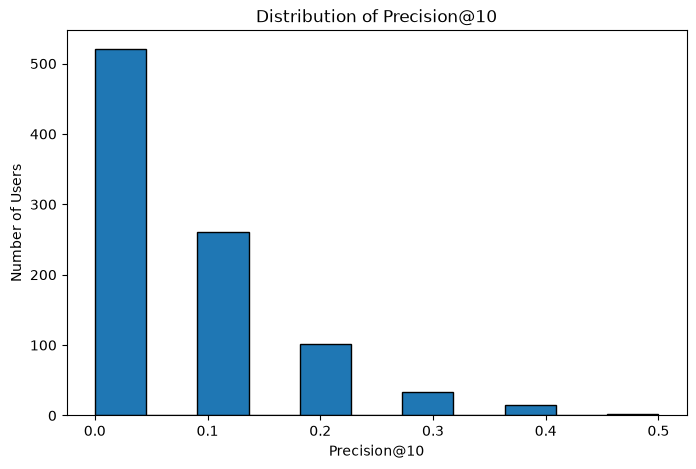

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(
    precision_scores,
    bins=11,
    edgecolor="black"
)

plt.xlabel("Precision@10")
plt.ylabel("Number of Users")
plt.title("Distribution of Precision@10")

plt.show()

## Evaluation Result

The user-based collaborative filtering model achieved an average Precision@10 of 0.0681 across 935 evaluated users.

This means that, on average, about 6.81% of the top 10 recommendations were relevant based on the held-out test ratings.

## Bonus: Item-Based Collaborative Filtering

I will also try item-based collaborative filtering.

Instead of finding similar users, this approach finds similar movies based on the ratings given by users.

### Movie-User Matrix

I will transpose the training user-item matrix so that each row represents a movie.

In [22]:
movie_user_matrix = train_user_item_matrix.T

movie_user_matrix.head()

print(
    "Movie-user matrix shape:",
    movie_user_matrix.shape
)

Movie-user matrix shape: (1655, 943)


### Movie Similarity

I will replace missing ratings with 0 and calculate the similarity between movies using cosine similarity.

In [23]:
movie_user_filled = movie_user_matrix.fillna(0)

movie_similarity = cosine_similarity(
    movie_user_filled
)

print(
    "Movie similarity matrix shape:",
    movie_similarity.shape
)

Movie similarity matrix shape: (1655, 1655)


### Recommendation Function

For each movie that the user liked, I will find similar movies and use their average similarity as the recommendation score.

In [24]:
def recommend_movies_item_based(
    user_id,
    top_k=10
):
    user_train_ratings = train_user_item_matrix.loc[
        user_id
    ]

    liked_movies = user_train_ratings[
        user_train_ratings >= 4
    ].index

    similar_movie_scores = {}
    similar_movie_counts = {}

    watched_movies = set(
        user_train_ratings.dropna().index
    )

    for movie_id in liked_movies:
        movie_index = movie_user_matrix.index.get_loc(
            movie_id
        )

        similarity_scores = movie_similarity[
            movie_index
        ]

        for similar_index, score in enumerate(
            similarity_scores
        ):
            similar_movie_id = (
                movie_user_matrix.index[similar_index]
            )

            if similar_movie_id == movie_id:
                continue

            if similar_movie_id in watched_movies:
                continue

            if similar_movie_id not in similar_movie_scores:
                similar_movie_scores[similar_movie_id] = 0
                similar_movie_counts[similar_movie_id] = 0

            similar_movie_scores[similar_movie_id] += score
            similar_movie_counts[similar_movie_id] += 1

    recommendation_scores = pd.Series(
        {
            movie_id:
            similar_movie_scores[movie_id]
            / similar_movie_counts[movie_id]
            for movie_id in similar_movie_scores
        }
    )

    return recommendation_scores.sort_values(
        ascending=False
    ).head(top_k)

### Example Recommendations

I will generate the top 10 item-based recommendations for User 1.

In [25]:
item_user_1 = recommend_movies_item_based(
    user_id=1,
    top_k=10
)

top_item_recommendations_df = (
    item_user_1
    .reset_index()
    .rename(
        columns={
            "index": "movie_id",
            0: "similarity_score"
        }
    )
    .merge(
        movies,
        on="movie_id",
        how="left"
    )
)

top_item_recommendations_df

,movie_id,similarity_score,title
0,204,0.359950,Back to the Future (1985)
1,89,0.330950,Blade Runner (1982)
2,423,0.330300,E.T. the Extra-Terrestrial (1982)
3,96,0.323379,Terminator 2: Judgment Day (1991)
4,318,0.317687,Schindler's List (1993)
5,655,0.312735,Stand by Me (1986)
6,64,0.311869,"Shawshank Redemption, The (1994)"
7,11,0.310563,Seven (Se7en) (1995)
8,568,0.308852,Speed (1994)
9,483,0.306774,Casablanca (1942)


## Item-Based Evaluation

I will evaluate the item-based recommendations using Precision@10 on the same held-out test data.

In [26]:
item_precision_scores = []

for user_id in test_ratings["user_id"].unique():
    user_test = test_ratings[
        test_ratings["user_id"] == user_id
    ]

    relevant_movies = set(
        user_test.loc[
            user_test["rating"] >= 4,
            "movie_id"
        ]
    )

    if len(relevant_movies) == 0:
        continue

    recommendations = recommend_movies_item_based(
        user_id,
        top_k=10
    )

    recommended_movies = set(
        recommendations.index
    )

    hits = recommended_movies.intersection(
        relevant_movies
    )

    precision = len(hits) / 10

    item_precision_scores.append(precision)

average_item_precision_at_10 = np.mean(
    item_precision_scores
)

print("Users evaluated:", len(item_precision_scores))
print(
    "Average Item-Based Precision@10:",
    average_item_precision_at_10
)

Users evaluated: 935
Average Item-Based Precision@10: 0.22631016042780752


## Item-Based Precision@10 Distribution

I will visualize the Precision@10 scores for the item-based recommendations.

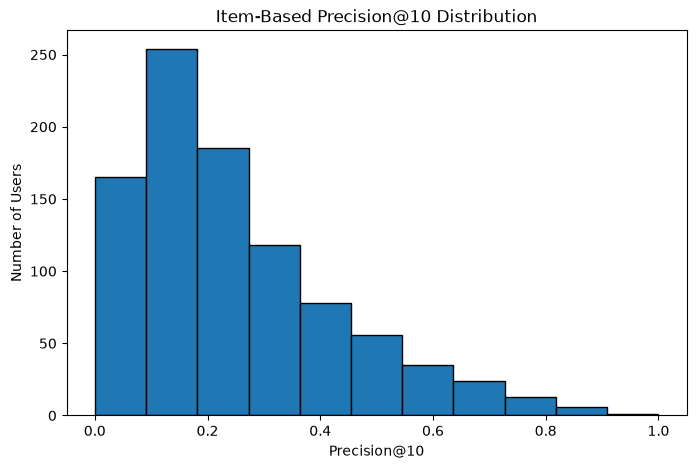

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(
    item_precision_scores,
    bins=11,
    edgecolor="black"
)

plt.xlabel("Precision@10")
plt.ylabel("Number of Users")
plt.title("Item-Based Precision@10 Distribution")

plt.show()

## Item-Based Evaluation Result

The item-based collaborative filtering model achieved an average Precision@10 of 0.2263 across 935 evaluated users.

This means that, on average, about 22.63% of the top 10 recommendations were relevant based on the held-out test ratings.

## Bonus: Matrix Factorization with SVD

I will also try SVD to learn hidden patterns in the user-movie ratings and predict ratings for movies the user has not rated.

In [28]:
from surprise import Dataset, Reader, SVD

### Preparing the Training Data

I will use the training ratings to train the SVD model and keep the test ratings for evaluation.

In [29]:
reader = Reader(
    rating_scale=(1, 5)
)

svd_train_data = Dataset.load_from_df(
    train_ratings[
        ["user_id", "movie_id", "rating"]
    ],
    reader
)

svd_trainset = svd_train_data.build_full_trainset()

print("Number of users:", svd_trainset.n_users)
print("Number of movies:", svd_trainset.n_items)
print("Number of ratings:", svd_trainset.n_ratings)

Number of users: 943
Number of movies: 1655
Number of ratings: 79619


### Training the SVD Model

I will start with the default SVD settings as a baseline.

In [30]:
svd_model = SVD(
    random_state=42
)

svd_model.fit(svd_trainset)

print("SVD model trained successfully.")

SVD model trained successfully.


### Predicting Ratings for Unseen Movies

I will predict ratings for movies that User 1 has not rated in the training data.

In [31]:
user_id = 1

watched_movies = set(
    train_ratings.loc[
        train_ratings["user_id"] == user_id,
        "movie_id"
    ]
)

train_movie_ids = set(
    train_user_item_matrix.columns
)

unseen_movies = train_movie_ids - watched_movies

svd_predictions = []

for movie_id in unseen_movies:
    prediction = svd_model.predict(
        user_id,
        movie_id
    )

    svd_predictions.append(
        {
            "movie_id": movie_id,
            "predicted_rating": prediction.est
        }
    )

svd_predictions = pd.DataFrame(
    svd_predictions
)

svd_predictions = svd_predictions.sort_values(
    "predicted_rating",
    ascending=False
)

print("Unseen movies:", len(svd_predictions))

svd_predictions.head(10)

Unseen movies: 1438


,movie_id,predicted_rating
190,408,4.767905
139,357,4.759117
385,603,4.679194
16,89,4.657281
27,127,4.605283
275,493,4.580627
293,511,4.579280
261,479,4.573238
225,443,4.563043
100,318,4.556967


## Evaluating SVD with Precision@10

I will evaluate the SVD model using Precision@10 on the same held-out test ratings.

In [32]:
svd_precision_scores = []

for user_id in test_ratings["user_id"].unique():
    user_test = test_ratings[
        test_ratings["user_id"] == user_id
    ]

    relevant_movies = set(
        user_test.loc[
            user_test["rating"] >= 4,
            "movie_id"
        ]
    )

    if len(relevant_movies) == 0:
        continue

    watched_movies = set(
        train_ratings.loc[
            train_ratings["user_id"] == user_id,
            "movie_id"
        ]
    )

    unseen_movies = (
        train_movie_ids - watched_movies
    )

    predictions = []

    for movie_id in unseen_movies:
        prediction = svd_model.predict(
            user_id,
            movie_id
        )

        predictions.append(
            (movie_id, prediction.est)
        )

    predictions = sorted(
        predictions,
        key=lambda x: x[1],
        reverse=True
    )

    recommended_movies = set(
        movie_id
        for movie_id, _ in predictions[:10]
    )

    hits = recommended_movies.intersection(
        relevant_movies
    )

    precision = len(hits) / 10

    svd_precision_scores.append(precision)

average_svd_precision_at_10 = np.mean(
    svd_precision_scores
)

print("Users evaluated:", len(svd_precision_scores))
print(
    "Average SVD Precision@10:",
    average_svd_precision_at_10
)

Users evaluated: 935
Average SVD Precision@10: 0.07390374331550802


## SVD Precision@10 Distribution

I will visualize the Precision@10 scores across the evaluated users.

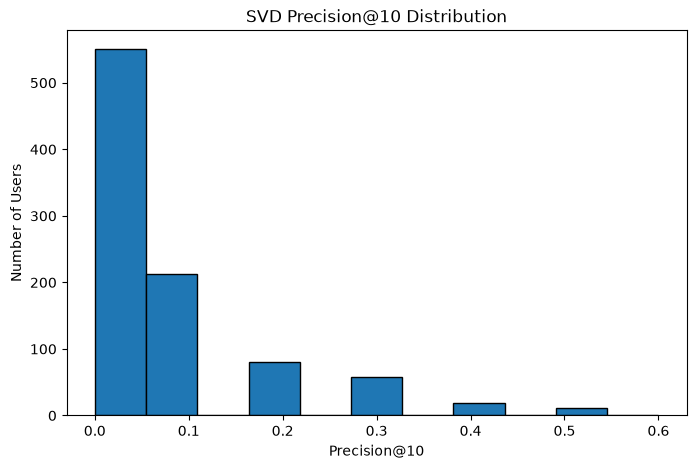

In [33]:
plt.figure(figsize=(8, 5))

plt.hist(
    svd_precision_scores,
    bins=11,
    edgecolor="black"
)

plt.xlabel("Precision@10")
plt.ylabel("Number of Users")
plt.title("SVD Precision@10 Distribution")

plt.show()

### SVD Evaluation Result

The baseline SVD model achieved an average Precision@10 of about 7.39% across 935 users.

### SVD Hyperparameter Tuning

We will try different SVD settings and compare their Precision@10 results.

In [46]:
svd_results = []
svd_models = {}

### SVD 1

We will first try SVD with 50 factors and 20 epochs.

In [35]:
svd_model_1 = SVD(
    n_factors=50,
    n_epochs=20,
    reg_all=0.02,
    random_state=42
)

svd_model_1.fit(svd_trainset)

svd_models["SVD 1"] = svd_model_1

In [36]:
svd_precision_scores_1 = []

for user_id in test_ratings["user_id"].unique():
    user_test = test_ratings[
        test_ratings["user_id"] == user_id
    ]

    relevant_movies = set(
        user_test.loc[
            user_test["rating"] >= 4,
            "movie_id"
        ]
    )

    if len(relevant_movies) == 0:
        continue

    watched_movies = set(
        train_ratings.loc[
            train_ratings["user_id"] == user_id,
            "movie_id"
        ]
    )

    unseen_movies = train_movie_ids - watched_movies

    predictions = []

    for movie_id in unseen_movies:
        prediction = svd_model_1.predict(
            user_id,
            movie_id
        )

        predictions.append(
            (movie_id, prediction.est)
        )

    predictions = sorted(
        predictions,
        key=lambda x: x[1],
        reverse=True
    )

    recommended_movies = set(
        movie_id
        for movie_id, _ in predictions[:10]
    )

    hits = recommended_movies.intersection(
        relevant_movies
    )

    precision = len(hits) / 10

    svd_precision_scores_1.append(precision)

average_precision_1 = np.mean(
    svd_precision_scores_1
)

svd_results.append(
    {
        "Model": "SVD 1",
        "Precision@10": average_precision_1
    }
)

print("Users evaluated:", len(svd_precision_scores_1))
print("SVD 1 Precision@10:", average_precision_1)

Users evaluated: 935
SVD 1 Precision@10: 0.07176470588235294


### SVD 2

We will increase the number of factors to 100 and keep the other settings the same.

In [37]:
svd_model_2 = SVD(
    n_factors=100,
    n_epochs=20,
    reg_all=0.02,
    random_state=42
)

svd_model_2.fit(svd_trainset)

svd_models["SVD 2"] = svd_model_2

In [38]:
svd_precision_scores_2 = []

for user_id in test_ratings["user_id"].unique():
    user_test = test_ratings[
        test_ratings["user_id"] == user_id
    ]

    relevant_movies = set(
        user_test.loc[
            user_test["rating"] >= 4,
            "movie_id"
        ]
    )

    if len(relevant_movies) == 0:
        continue

    watched_movies = set(
        train_ratings.loc[
            train_ratings["user_id"] == user_id,
            "movie_id"
        ]
    )

    unseen_movies = train_movie_ids - watched_movies

    predictions = []

    for movie_id in unseen_movies:
        prediction = svd_model_2.predict(
            user_id,
            movie_id
        )

        predictions.append(
            (movie_id, prediction.est)
        )

    predictions = sorted(
        predictions,
        key=lambda x: x[1],
        reverse=True
    )

    recommended_movies = set(
        movie_id
        for movie_id, _ in predictions[:10]
    )

    hits = recommended_movies.intersection(
        relevant_movies
    )

    precision = len(hits) / 10

    svd_precision_scores_2.append(precision)

average_precision_2 = np.mean(
    svd_precision_scores_2
)

svd_results.append(
    {
        "Model": "SVD 2",
        "Precision@10": average_precision_2
    }
)

print("Users evaluated:", len(svd_precision_scores_2))
print("SVD 2 Precision@10:", average_precision_2)

Users evaluated: 935
SVD 2 Precision@10: 0.07390374331550802


### SVD 3

We will increase the training epochs and regularization to see if the recommendation performance improves.

In [39]:
svd_model_3 = SVD(
    n_factors=100,
    n_epochs=30,
    reg_all=0.05,
    random_state=42
)

svd_model_3.fit(svd_trainset)

svd_models["SVD 3"] = svd_model_3

In [40]:
svd_precision_scores_3 = []

for user_id in test_ratings["user_id"].unique():
    user_test = test_ratings[
        test_ratings["user_id"] == user_id
    ]

    relevant_movies = set(
        user_test.loc[
            user_test["rating"] >= 4,
            "movie_id"
        ]
    )

    if len(relevant_movies) == 0:
        continue

    watched_movies = set(
        train_ratings.loc[
            train_ratings["user_id"] == user_id,
            "movie_id"
        ]
    )

    unseen_movies = train_movie_ids - watched_movies

    predictions = []

    for movie_id in unseen_movies:
        prediction = svd_model_3.predict(
            user_id,
            movie_id
        )

        predictions.append(
            (movie_id, prediction.est)
        )

    predictions = sorted(
        predictions,
        key=lambda x: x[1],
        reverse=True
    )

    recommended_movies = set(
        movie_id
        for movie_id, _ in predictions[:10]
    )

    hits = recommended_movies.intersection(
        relevant_movies
    )

    precision = len(hits) / 10

    svd_precision_scores_3.append(precision)

average_precision_3 = np.mean(
    svd_precision_scores_3
)

svd_results.append(
    {
        "Model": "SVD 3",
        "Precision@10": average_precision_3
    }
)

print("Users evaluated:", len(svd_precision_scores_3))
print("SVD 3 Precision@10:", average_precision_3)

Users evaluated: 935
SVD 3 Precision@10: 0.0762566844919786


### SVD Tuning Results

Now we can compare the three SVD configurations based on Precision@10.

In [41]:
svd_results_df = pd.DataFrame(svd_results)

svd_results_df

,Model,Precision@10
0,SVD 1,0.071765
1,SVD 2,0.073904
2,SVD 3,0.076257


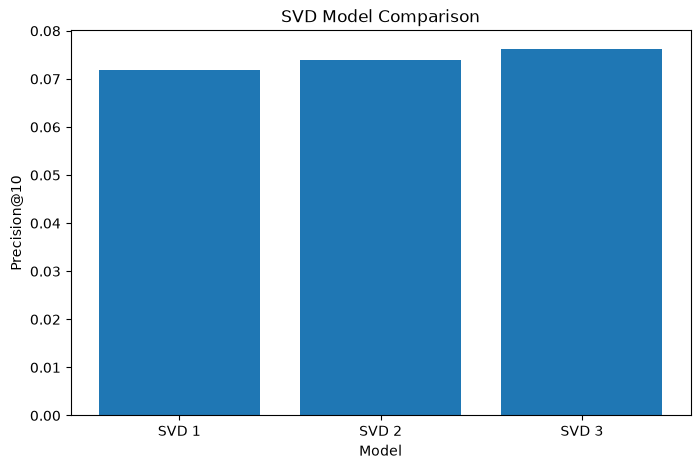

In [42]:
plt.figure(figsize=(8, 5))

plt.bar(
    svd_results_df["Model"],
    svd_results_df["Precision@10"]
)

plt.xlabel("Model")
plt.ylabel("Precision@10")
plt.title("SVD Model Comparison")

plt.show()

### Selecting the Final SVD Model

We will select the model with the highest Precision@10 as the final SVD model.

In [43]:
best_model_name = svd_results_df.loc[
    svd_results_df["Precision@10"].idxmax(),
    "Model"
]

best_svd_model = svd_models[best_model_name]

best_precision = svd_results_df.loc[
    svd_results_df["Model"] == best_model_name,
    "Precision@10"
].iloc[0]

print("Best SVD model:", best_model_name)
print("Best Precision@10:", best_precision)

Best SVD model: SVD 3
Best Precision@10: 0.0762566844919786


### Final SVD Recommendations

We will use the selected SVD model to generate recommendations for User 1.

In [44]:
user_id = 1

watched_movies = set(
    train_ratings.loc[
        train_ratings["user_id"] == user_id,
        "movie_id"
    ]
)

unseen_movies = train_movie_ids - watched_movies

predictions = []

for movie_id in unseen_movies:
    prediction = best_svd_model.predict(
        user_id,
        movie_id
    )

    predictions.append(
        (movie_id, prediction.est)
    )

predictions = sorted(
    predictions,
    key=lambda x: x[1],
    reverse=True
)

final_recommendations = predictions[:10]

final_recommendations_df = pd.DataFrame(
    final_recommendations,
    columns=["movie_id", "predicted_rating"]
)

final_recommendations_df = final_recommendations_df.merge(
    movies,
    on="movie_id",
    how="left"
)

final_recommendations_df

,movie_id,predicted_rating,title
0,408,4.716236,"Close Shave, A (1995)"
1,89,4.684099,Blade Runner (1982)
2,511,4.683299,Lawrence of Arabia (1962)
3,357,4.678556,One Flew Over the Cuckoo's Nest (1975)
4,127,4.658956,"Godfather, The (1972)"
5,661,4.605676,High Noon (1952)
6,603,4.571137,Rear Window (1954)
7,64,4.564009,"Shawshank Redemption, The (1994)"
8,527,4.558947,Gandhi (1982)
9,493,4.531220,"Thin Man, The (1934)"


### Saving the Final Model

We will save the selected SVD model for future use.

In [45]:
os.makedirs("artifacts", exist_ok=True)

joblib.dump(
    {
        "model": best_svd_model,
        "train_movie_ids": train_movie_ids,
        "movies": movies
    },
    "artifacts/movie_recommendation_svd.pkl"
)

print("Final SVD model saved successfully.")

Final SVD model saved successfully.


## Final Conclusion

Three recommendation approaches were implemented and evaluated using Precision@10.

- User-based collaborative filtering achieved a Precision@10 of 6.81%.
- Item-based collaborative filtering achieved a Precision@10 of 22.63%.
- The tuned SVD model achieved a Precision@10 of about 7.63%.

The tuned SVD model was selected as the final model for the Streamlit application because it achieved the highest Precision@10 among the tested SVD configurations.

The final model was saved in `artifacts/movie_recommendation_svd.pkl` and used in the application to generate personalized top-10 movie recommendations.